# Basal ganglia direct loop: connectivity heatmaps

Applies PathFinder's joint decomposition to the direct basal-ganglia loop
(group-averaged tractography across 10 subjects) and visualises the true vs
reconstructed connectivity matrices, sorted by winner-takes-all component.

In [1]:
import os, sys
import numpy as np
import scipy.sparse as sps
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment

sys.path.insert(0, os.path.abspath('..'))
from pathfinder.decomp import JointOuterDecomp

BASE_PATH = os.path.join('..', 'data', 'group_average_n10')
N_COMPONENTS = 5
N_ITER = 50

## Direct loop: 2x2 grid

Rows: Thalamus, Striatum. Columns: Cortex, GPi. The four observed cells tile
the direct pathway (Cortex -> Striatum -> GPi -> Thalamus -> Cortex) into a
2x2 block matrix.

In [2]:
DIRECT_LOOP = {
    'row_regions': ['Thalamus', 'Striatum'],
    'col_regions': ['Cortex', 'GPi'],
    'blocks': [
        ('thalamus', 'cortex',   False),  # (0,0) Thal->Ctx
        ('GPi',      'thalamus', True),   # (0,1) (GPi->Thal)^T
        ('cortex',   'striatum', True),   # (1,0) (Ctx->Stri)^T
        ('striatum', 'GPi',      False),  # (1,1) Stri->GPi
    ],
    'alpha': [0, 0, 1, 1],
    'beta':  [0, 1, 0, 1],
}

In [3]:
def load_spmat(matfile):
    """Load sparse matrix from FSL fdt_matrix2.dot format."""
    mat = np.loadtxt(matfile)
    v = mat[:-1, -1]
    r = (mat[:-1, 0] - 1).astype(int)
    c = (mat[:-1, 1] - 1).astype(int)
    nr, nc = int(mat[-1, 0]), int(mat[-1, 1])
    return sps.csc_matrix((v, (r, c)), shape=(nr, nc)).toarray()


def load_blocks(loop_def):
    """Load raw and log-normalised connectivity matrices."""
    Clist_raw, Clist = [], []
    for seed, target, do_transpose in loop_def['blocks']:
        path = os.path.join(BASE_PATH, f'L_{seed}_2_L_{target}', 'fdt_matrix2.dot')
        mat = load_spmat(path)
        if do_transpose:
            mat = mat.T
        Clist_raw.append(mat)
        proc = np.log1p(mat)
        fnorm = np.linalg.norm(proc, 'fro')
        Clist.append(proc / fnorm if fnorm > 0 else proc)
        print(f'  {seed}->{target}: {mat.shape}')
    return Clist, Clist_raw

In [4]:
Clist, Clist_raw = load_blocks(DIRECT_LOOP)

np.random.seed(0)
model = JointOuterDecomp(
    n_components=N_COMPONENTS, n_iter=N_ITER, alpha=1e-5,
    batch_size=128, init_type='svd', do_ica='both', verbose=True,
)
model.fit(Clist, alpha=DIRECT_LOOP['alpha'], beta=DIRECT_LOOP['beta'])
print(f'Final loss: {np.mean(model._loss[-1]):.6f}')

  thalamus->cortex: (1139, 56324)
  GPi->thalamus: (1139, 215)
  cortex->striatum: (1275, 56324)
  striatum->GPi: (1275, 215)
Initialising A and S with svd...
Iteration   50/50 [100.0%] | Loss: 0.456539
Final loss: 0.456539


## Sort voxels by winner-takes-all component

`find_permutation` aligns components so that diagonal blocks carry the most
energy; `sort_order` then orders voxels by dominant component and loading
strength so the reorganised heatmaps show a block-diagonal structure.

In [5]:
def find_permutation(model, Clist_raw, loop_def):
    K = model._A[0].shape[1]
    coupling = np.zeros((K, K))
    for k in range(len(Clist_raw)):
        orig = np.log1p(Clist_raw[k].astype(np.float64))
        p, q = loop_def['alpha'][k], loop_def['beta'][k]
        row_wta = np.argmax(np.abs(model._A[p]), axis=1)
        col_wta = np.argmax(np.abs(model._S[q]), axis=1)
        for ci in range(K):
            rm = row_wta == ci
            if not rm.any():
                continue
            for cj in range(K):
                cm = col_wta == cj
                if not cm.any():
                    continue
                coupling[ci, cj] += orig[np.ix_(rm, cm)].sum() / (rm.sum() * cm.sum())
    _, perm = linear_sum_assignment(-coupling)
    return perm


def sort_order(factor_mat, perm):
    abs_F = np.abs(factor_mat)
    dominant = np.argsort(perm)[np.argmax(abs_F, axis=1)]
    strength = np.max(abs_F, axis=1)
    return np.lexsort((-strength, dominant))


def component_boundaries(factor_mat, perm):
    dominant = np.argsort(perm)[np.argmax(np.abs(factor_mat), axis=1)]
    K = factor_mat.shape[1]
    bounds, cum = [], 0
    for c in range(K - 1):
        cum += int((dominant == c).sum())
        bounds.append(cum)
    return bounds

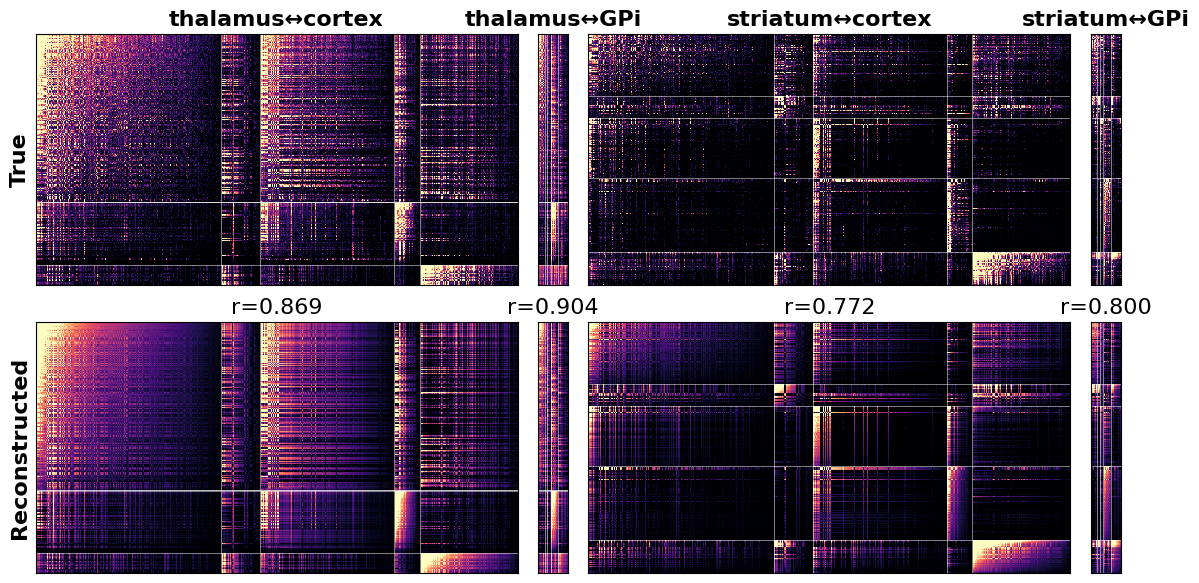

In [10]:
def plot_heatmaps(model, Clist, Clist_raw, loop_def):
    n_mat = len(Clist)
    Cpred = model.predict()
    perm = find_permutation(model, Clist_raw, loop_def)

    widths = np.sqrt([Clist[k].shape[1] for k in range(n_mat)])
    widths /= widths.min()

    fig, axes = plt.subplots(2, n_mat, figsize=(3.5 * n_mat, 7),
                             gridspec_kw={'width_ratios': widths,
                                          'wspace': 0.08, 'hspace': 0.15})

    for k in range(n_mat):
        orig = np.log1p(Clist_raw[k].astype(np.float64))
        fnorm = np.linalg.norm(orig, 'fro')
        pred = Cpred[k] * fnorm if fnorm > 0 else Cpred[k]

        p, q = loop_def['alpha'][k], loop_def['beta'][k]
        ro = sort_order(model._A[p], perm)
        co = sort_order(model._S[q], perm)
        orig = orig[np.ix_(ro, co)]
        pred = pred[np.ix_(ro, co)]

        rb = component_boundaries(model._A[p], perm)
        cb = component_boundaries(model._S[q], perm)

        nz = orig[orig > 0]
        vmax = np.percentile(nz, 95) if len(nz) else 1.0

        seed, target, transposed = loop_def['blocks'][k]
        label = f'{target}↔{seed}' if transposed else f'{seed}↔{target}'
        r = np.corrcoef(orig.ravel(), pred.ravel())[0, 1]

        for row, (mat, title) in enumerate([(orig, label), (pred, f'r={r:.3f}')]):
            ax = axes[row, k]
            ax.imshow(mat, aspect='auto', cmap='magma', vmin=0, vmax=vmax,
                      interpolation='none')
            ax.set_title(title, fontsize=16,
                         fontweight='bold' if row == 0 else 'normal')
            for b in rb:
                ax.axhline(b - 0.5, color='white', lw=0.5, alpha=0.7)
            for b in cb:
                ax.axvline(b - 0.5, color='white', lw=0.5, alpha=0.7)
            ax.set_xticks([]); ax.set_yticks([])
            if k == 0:
                ax.set_ylabel('True' if row == 0 else 'Reconstructed',
                              fontsize=16, fontweight='bold')
    return fig


fig = plot_heatmaps(model, Clist, Clist_raw, DIRECT_LOOP)
plt.show()